**Sprint 3 / IA & Machine Learning**

Nessa sprint utilizamos um autoencoder para achar possíveis anomalias nos detalhes técnicos de veículos. Foi criada uma base sintética para os testes, feita a preparação dos dados e comparadas três configurações do modelo com diferentes tamanhos de gargalo.
Como escolhemos o desafio 1, também fizemos uma função que recebe o veículo e os atributos que queremos consultar. O autoencoder foi usado pra tentar identificar dados que fogem do padrão.

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

Eduardo da Silva Lima (RM: 554804)

Enzo Bonacasatta (RM: 555372)

Guilherme Ulacco (RM: 558418)

Matheus Hostim (RM: 556517)

Estevam Melo (RM: 555124)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [2]:
n_normal = 1000

tamanho = np.random.uniform(0, 1, n_normal)
desempenho = np.random.uniform(0, 1, n_normal)

motor_litros = np.clip(
    1.0 + (4.5 * tamanho) + np.random.normal(0, 0.15, n_normal),
    1.0, 6.0
)

cilindros = np.select(
    [
        motor_litros < 1.6,
        motor_litros < 2.5,
        motor_litros < 4.0
    ],
    [3, 4, 6],
    default=8
)

potencia_cv = (
    70
    + (85 * motor_litros)
    + (70 * desempenho)
    + np.random.normal(0, 25, n_normal)
)

torque_nm = (
    100
    + (125 * motor_litros)
    + (80 * desempenho)
    + np.random.normal(0, 30, n_normal)
)

marchas = np.clip(
    np.rint(5 + (2 * desempenho) + (2 * tamanho) +
            np.random.normal(0, 0.6, n_normal)),
    5, 10
).astype(int)

zero_100_s = np.clip(
    13.0
    - (2.7 * desempenho)
    - (1.2 * tamanho)
    - (0.7 * (motor_litros - 1))
    + np.random.normal(0, 0.5, n_normal),
    4.5, 13.0
)

diametro_roda_pol = np.clip(
    np.rint(
        15
        + (4 * tamanho)
        + np.random.normal(0, 0.7, n_normal)
    ),
    15, 22
).astype(int)

largura_pneu_mm = np.clip(
    np.rint(
        185
        + (80 * tamanho)
        + (45 * desempenho)
        + np.random.normal(0, 10, n_normal)
    ),
    185, 325
).astype(int)

perfil_pneu = np.clip(
    np.rint(
        75
        - (25 * tamanho)
        - (10 * desempenho)
        + np.random.normal(0, 4, n_normal)
    ),
    35, 75
).astype(int)

tracao_4x4 = (
    np.random.rand(n_normal) < (0.15 + 0.60 * tamanho)
).astype(int)

modos_conducao = np.clip(
    np.rint(
        2
        + (4 * desempenho)
        + np.random.normal(0, 0.6, n_normal)
    ),
    2, 7
).astype(int)

modos_volante = np.clip(
    np.rint(1 + (2 * desempenho) + np.random.normal(0, 0.4, n_normal)),
    1, 3
).astype(int)

modos_escapamento = np.clip(
    np.rint(1 + (3 * desempenho) + np.random.normal(0, 0.5, n_normal)),
    1, 4
).astype(int)

modos_amortecedor = np.clip(
    np.rint(1 + (2 * desempenho) + np.random.normal(0, 0.4, n_normal)),
    1, 3
).astype(int)

matrix_led = (
    np.random.rand(n_normal) < (0.15 + 0.65 * desempenho)
).astype(int)

# Montagem do DataFrame
df_normal = pd.DataFrame({
    "motor_litros": motor_litros,
    "cilindros": cilindros,
    "potencia_cv": potencia_cv,
    "torque_nm": torque_nm,
    "marchas": marchas,
    "zero_100_s": zero_100_s,
    "diametro_roda_pol": diametro_roda_pol,
    "largura_pneu_mm": largura_pneu_mm,
    "perfil_pneu": perfil_pneu,
    "tracao_4x4": tracao_4x4,
    "modos_conducao": modos_conducao,
    "modos_volante": modos_volante,
    "modos_escapamento": modos_escapamento,
    "modos_amortecedor": modos_amortecedor,
    "matrix_led": matrix_led
})

df_normal["anomalia"] = 0

print("Quantidade de registros:", len(df_normal))
df_normal.head()

Quantidade de registros: 1000


,motor_litros,cilindros,potencia_cv,torque_nm,marchas,zero_100_s,diametro_roda_pol,largura_pneu_mm,perfil_pneu,tracao_4x4,modos_conducao,modos_volante,modos_escapamento,modos_amortecedor,matrix_led,anomalia
0,2.553733,6,346.800752,444.428577,7,10.876765,17,208,66,1,3,1,2,1,1,0
1,5.154182,8,555.778918,862.971563,7,7.807421,18,274,46,0,3,2,2,2,1,0
2,4.260001,8,471.498967,647.133448,8,7.450866,18,291,52,1,5,3,4,3,0,0
3,3.749068,6,453.292250,626.243073,7,7.654791,16,268,53,0,5,3,2,3,0,0
4,1.839122,4,216.890921,413.631377,6,10.085466,16,247,62,0,5,2,3,2,1,0


In [3]:
n_anomalias = 200

indices = np.random.choice(
    len(df_normal),
    size=n_anomalias,
    replace=True
)

df_anomalias = df_normal.iloc[indices].copy().reset_index(drop=True)

# Criamos alterações em alguns atributos para ter exemplos de anomalias nos testes.
tipos_anomalia = np.random.choice(
    [
        "potencia",
        "torque",
        "motor",
        "marchas",
        "zero_100",
        "roda_pneu",
        "modos"
    ],
    size=n_anomalias
)

for i, tipo in enumerate(tipos_anomalia):

    if tipo == "potencia":
        df_anomalias.loc[i, "potencia_cv"] *= np.random.uniform(0.4, 1.8)

    elif tipo == "torque":
        df_anomalias.loc[i, "torque_nm"] *= np.random.uniform(0.4, 1.8)

    elif tipo == "motor":
        df_anomalias.loc[i, "motor_litros"] = np.random.uniform(0.8, 7.0)

    elif tipo == "marchas":
        df_anomalias.loc[i, "marchas"] = np.random.choice([3, 4, 11, 12])

    elif tipo == "zero_100":
        df_anomalias.loc[i, "zero_100_s"] = np.random.uniform(2.0, 20.0)

    elif tipo == "roda_pneu":
        df_anomalias.loc[i, "diametro_roda_pol"] = np.random.choice(
            [12, 13, 24, 26]
        )
        df_anomalias.loc[i, "largura_pneu_mm"] = np.random.choice(
            [120, 140, 380, 420]
        )

    elif tipo == "modos":
        df_anomalias.loc[i, "modos_conducao"] = np.random.choice(
            [0, 1, 9, 12]
        )
        df_anomalias.loc[i, "modos_amortecedor"] = np.random.choice(
            [0, 5, 7]
        )

df_anomalias["anomalia"] = 1

df = pd.concat(
    [df_normal, df_anomalias],
    ignore_index=True
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Registros normais:", (df["anomalia"] == 0).sum())
print("Registros anômalos:", (df["anomalia"] == 1).sum())
print("Total de registros:", len(df))

df.head()

Registros normais: 1000
Registros anômalos: 200
Total de registros: 1200


,motor_litros,cilindros,potencia_cv,torque_nm,marchas,zero_100_s,diametro_roda_pol,largura_pneu_mm,perfil_pneu,tracao_4x4,modos_conducao,modos_volante,modos_escapamento,modos_amortecedor,matrix_led,anomalia
0,1.206623,3,219.652947,221.196981,5,11.705133,15,193,75,0,3,1,1,1,1,1
1,3.569470,6,444.217167,562.687928,7,8.736794,17,273,53,1,7,3,3,3,1,0
2,3.810872,6,487.525811,629.117588,9,8.216240,18,284,49,1,5,2,4,2,0,0
3,1.479213,3,257.926351,324.638334,7,10.901859,16,222,70,0,5,2,3,2,1,0
4,1.159751,3,218.458188,284.379761,6,11.868003,16,213,67,0,5,2,2,2,1,0


In [4]:
print("Dimensões da base:", df.shape)

print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nEstatísticas descritivas:")
display(df.describe().T)

Dimensões da base: (1200, 16)

Tipos de dados:
motor_litros         float64
cilindros              int64
potencia_cv          float64
torque_nm            float64
marchas                int64
zero_100_s           float64
diametro_roda_pol      int64
largura_pneu_mm        int64
perfil_pneu            int64
tracao_4x4             int64
modos_conducao         int64
modos_volante          int64
modos_escapamento      int64
modos_amortecedor      int64
matrix_led             int64
anomalia               int64
dtype: object

Valores ausentes:
motor_litros         0
cilindros            0
potencia_cv          0
torque_nm            0
marchas              0
zero_100_s           0
diametro_roda_pol    0
largura_pneu_mm      0
perfil_pneu          0
tracao_4x4           0
modos_conducao       0
modos_volante        0
modos_escapamento    0
modos_amortecedor    0
matrix_led           0
anomalia             0
dtype: int64

Registros duplicados:
0

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
motor_litros,1200.0,3.231394,1.331400,0.838069,2.046414,3.268435,4.352151,6.970757
cilindros,1200.0,5.795833,1.834017,3.000000,4.000000,6.000000,8.000000,8.000000
potencia_cv,1200.0,380.477300,119.549811,104.146646,283.284604,380.356971,473.675367,809.405805
torque_nm,1200.0,542.939400,174.529873,150.541356,404.219923,539.526731,678.879692,1241.610934
marchas,1200.0,6.973333,1.159199,3.000000,6.000000,7.000000,8.000000,12.000000
zero_100_s,1200.0,9.483862,1.727529,3.884412,8.275861,9.493009,10.598713,19.769547
diametro_roda_pol,1200.0,17.082500,1.717504,12.000000,16.000000,17.000000,18.000000,26.000000
largura_pneu_mm,1200.0,247.510000,35.285324,120.000000,226.000000,247.000000,268.250000,420.000000
perfil_pneu,1200.0,57.678333,8.560136,35.000000,51.000000,57.000000,64.000000,75.000000
tracao_4x4,1200.0,0.440833,0.496694,0.000000,0.000000,0.000000,1.000000,1.000000


In [5]:
features = [
    "motor_litros",
    "cilindros",
    "potencia_cv",
    "torque_nm",
    "marchas",
    "zero_100_s",
    "diametro_roda_pol",
    "largura_pneu_mm",
    "perfil_pneu",
    "tracao_4x4",
    "modos_conducao",
    "modos_volante",
    "modos_escapamento",
    "modos_amortecedor",
    "matrix_led"
]

outliers = {}

for coluna in features:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    quantidade = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    outliers[coluna] = quantidade

outliers_df = pd.DataFrame(
    list(outliers.items()),
    columns=["variavel", "quantidade_outliers"]
)

outliers_df = outliers_df.sort_values(
    "quantidade_outliers",
    ascending=False
)

# Os outliers não foram removidos porque parte deles representa as anomalias que queremos detectar

display(outliers_df)

,variavel,quantidade_outliers
7,largura_pneu_mm,28
6,diametro_roda_pol,24
10,modos_conducao,15
5,zero_100_s,13
13,modos_amortecedor,10
4,marchas,3
2,potencia_cv,3
3,torque_nm,1
1,cilindros,0
0,motor_litros,0


In [6]:
# O autoencoder treina apenas com registros normais para aprender o padrão deles

X_normal = df_normal[features]

X_train_normal, X_test_normal = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

X_test_anomalias = df_anomalias[features]

X_test = pd.concat(
    [X_test_normal, X_test_anomalias],
    ignore_index=True
)

y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_test_anomalias))
])

indices_teste = np.random.RandomState(42).permutation(len(X_test))

X_test = X_test.iloc[indices_teste].reset_index(drop=True)
y_test = y_test[indices_teste]

print("Treinamento:", X_train_normal.shape)
print("Teste:", X_test.shape)

print("\nRegistros normais no teste:", (y_test == 0).sum())
print("Registros anômalos no teste:", (y_test == 1).sum())

Treinamento: (800, 15)
Teste: (400, 15)

Registros normais no teste: 200
Registros anômalos no teste: 200


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

print("Formato do treinamento:", X_train_scaled.shape)
print("Formato do teste:", X_test_scaled.shape)

Formato do treinamento: (800, 15)
Formato do teste: (400, 15)


In [8]:
# Usamos o autoencoder porque o foco é encontrar registros que fogem do padrão normal

input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation="relu")(input_layer)
encoded = Dense(4, activation="relu")(encoded)
decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder_1 = Model(
    input_layer,
    decoded
)

autoencoder_1.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339 (1.32 KB)

 Trainable params: 339 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_1 = autoencoder_1.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 1.0567 - val_loss: 1.0496
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.0110 - val_loss: 1.0211
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.9824 - val_loss: 0.9966
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9556 - val_loss: 0.9665
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9207 - val_loss: 0.9215
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.8724 - val_loss: 0.8611
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8143 - val_loss: 0.7925
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7503 - val_loss: 0.7199
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6804 - val_loss: 0.6448
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6054 - val_loss: 0.5677
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5319 - val_loss: 0.4986
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

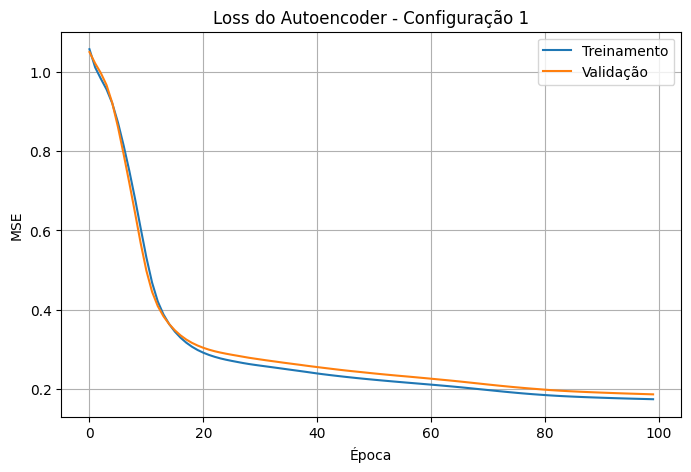

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_1.history["loss"],
    label="Treinamento"
)

plt.plot(
    history_1.history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Loss do Autoencoder - Configuração 1")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
X_test_pred_1 = autoencoder_1.predict(
    X_test_scaled,
    verbose=0
)

reconstruction_error_1 = np.mean(
    np.square(X_test_scaled - X_test_pred_1),
    axis=1
)

erro_normal = reconstruction_error_1[y_test == 0]
erro_anomalia = reconstruction_error_1[y_test == 1]

print("Erro médio - registros normais:",
      erro_normal.mean())

print("Erro médio - registros anômalos:",
      erro_anomalia.mean())

print("\nMediana - registros normais:",
      np.median(erro_normal))

print("Mediana - registros anômalos:",
      np.median(erro_anomalia))

Erro médio - registros normais: 0.1767724606391209
Erro médio - registros anômalos: 1.210430683835066

Mediana - registros normais: 0.16525345901580094
Mediana - registros anômalos: 0.5953485686474561


In [12]:
X_train_pred_1 = autoencoder_1.predict(
    X_train_scaled,
    verbose=0
)

reconstruction_error_train_1 = np.mean(
    np.square(X_train_scaled - X_train_pred_1),
    axis=1
)

# Definindo o limite pelo percentil 95
threshold_1 = np.percentile(
    reconstruction_error_train_1,
    95
)

print("Threshold:", threshold_1)

y_pred_1 = (
    reconstruction_error_1 > threshold_1
).astype(int)

accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1, zero_division=0)
recall_1 = recall_score(y_test, y_pred_1, zero_division=0)
f1_1 = f1_score(y_test, y_pred_1, zero_division=0)
print("\nAccuracy:", accuracy_1)
print("Precision:", precision_1)
print("Recall:", recall_1)
print("F1:", f1_1)
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_1))

Threshold: 0.33480763885129544

Accuracy: 0.7975
Precision: 0.8993288590604027
Recall: 0.67
F1: 0.7679083094555874

Matriz de confusão:
[[185  15]
 [ 66 134]]


In [13]:
input_layer_2 = Input(shape=(input_dim,))
encoded_2 = Dense(8, activation="relu")(input_layer_2)
encoded_2 = Dense(2, activation="relu")(encoded_2)
decoded_2 = Dense(8, activation="relu")(encoded_2)
decoded_2 = Dense(input_dim, activation="linear")(decoded_2)

autoencoder_2 = Model(
    input_layer_2,
    decoded_2
)

autoencoder_2.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stopping_2 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_2 = autoencoder_2.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_2],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.1358 - val_loss: 1.0822
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0400 - val_loss: 1.0324
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9926 - val_loss: 1.0025
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9589 - val_loss: 0.9709
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9239 - val_loss: 0.9314
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8829 - val_loss: 0.8837
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8392 - val_loss: 0.8363
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7975 - val_loss: 0.7938
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7603 - val_loss: 0.7580
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7288 - val_loss: 0.7286
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7031 - val_loss: 0.7053
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [15]:
def avaliar_autoencoder(modelo, X_treino, X_teste, y_teste):
    X_treino_pred = modelo.predict(
        X_treino,
        verbose=0
    )

    erro_treino = np.mean(
        np.square(X_treino - X_treino_pred),
        axis=1
    )

    threshold = np.percentile(
        erro_treino,
        95
    )

    X_teste_pred = modelo.predict(
        X_teste,
        verbose=0
    )

    erro_teste = np.mean(
        np.square(X_teste - X_teste_pred),
        axis=1
    )

    y_pred = (
        erro_teste > threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_teste,
        y_pred
    )

    precision = precision_score(
        y_teste,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_teste,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_teste,
        y_pred,
        zero_division=0
    )

    matriz = confusion_matrix(
        y_teste,
        y_pred
    )

    erro_normal = erro_teste[y_teste == 0]
    erro_anomalia = erro_teste[y_teste == 1]

    return {
        "threshold": threshold,
        "erro_normal_medio": erro_normal.mean(),
        "erro_anomalia_medio": erro_anomalia.mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "matriz": matriz
    }


resultado_1 = avaliar_autoencoder(
    autoencoder_1,
    X_train_scaled,
    X_test_scaled,
    y_test
)

resultado_2 = avaliar_autoencoder(
    autoencoder_2,
    X_train_scaled,
    X_test_scaled,
    y_test
)

print("CONFIGURAÇÃO 1")
print("Threshold:", resultado_1["threshold"])
print("Erro médio - normais:", resultado_1["erro_normal_medio"])
print("Erro médio - anômalos:", resultado_1["erro_anomalia_medio"])
print("Accuracy:", resultado_1["accuracy"])
print("Precision:", resultado_1["precision"])
print("Recall:", resultado_1["recall"])
print("F1:", resultado_1["f1"])
print("Matriz de confusão:")
print(resultado_1["matriz"])
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
print("CONFIGURAÇÃO 2")
print("Threshold:", resultado_2["threshold"])
print("Erro médio - normais:", resultado_2["erro_normal_medio"])
print("Erro médio - anômalos:", resultado_2["erro_anomalia_medio"])
print("Accuracy:", resultado_2["accuracy"])
print("Precision:", resultado_2["precision"])
print("Recall:", resultado_2["recall"])
print("F1:", resultado_2["f1"])
print("Matriz de confusão:")
print(resultado_2["matriz"])

CONFIGURAÇÃO 1
Threshold: 0.33480763885129544
Erro médio - normais: 0.1767724606391209
Erro médio - anômalos: 1.210430683835066
Accuracy: 0.7975
Precision: 0.8993288590604027
Recall: 0.67
F1: 0.7679083094555874
Matriz de confusão:
[[185  15]
 [ 66 134]]
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
CONFIGURAÇÃO 2
Threshold: 0.45615679404346504
Erro médio - normais: 0.2690719737212045
Erro médio - anômalos: 1.3248079565136102
Accuracy: 0.7825
Precision: 0.9124087591240876
Recall: 0.625
F1: 0.7418397626112759
Matriz de confusão:
[[188  12]
 [ 75 125]]


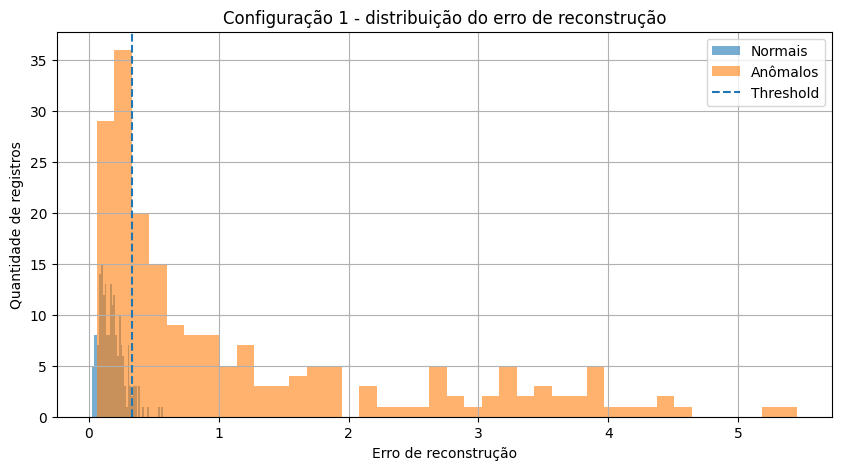

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    reconstruction_error_1[y_test == 0],
    bins=40,
    alpha=0.6,
    label="Normais"
)

plt.hist(
    reconstruction_error_1[y_test == 1],
    bins=40,
    alpha=0.6,
    label="Anômalos"
)

plt.axvline(
    threshold_1,
    linestyle="--",
    label="Threshold"
)

plt.xlabel("Erro de reconstrução")
plt.ylabel("Quantidade de registros")
plt.title("Configuração 1 - distribuição do erro de reconstrução")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
input_layer_3 = Input(shape=(input_dim,))

encoded_3 = Dense(8, activation="relu")(input_layer_3)
encoded_3 = Dense(6, activation="relu")(encoded_3)

decoded_3 = Dense(8, activation="relu")(encoded_3)
decoded_3 = Dense(input_dim, activation="linear")(decoded_3)

autoencoder_3 = Model(
    input_layer_3,
    decoded_3
)

autoencoder_3.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder_3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373 (1.46 KB)

 Trainable params: 373 (1.46 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping_3 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_3 = autoencoder_3.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_3],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0096 - val_loss: 1.0254
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9789 - val_loss: 0.9994
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9474 - val_loss: 0.9655
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9021 - val_loss: 0.9148
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8376 - val_loss: 0.8454
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7636 - val_loss: 0.7721
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6974 - val_loss: 0.7101
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6455 - val_loss: 0.6611
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6034 - val_loss: 0.6189
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5660 - val_loss: 0.5807
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5327 - val_loss: 0.5465
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [19]:
resultado_3 = avaliar_autoencoder(
    autoencoder_3,
    X_train_scaled,
    X_test_scaled,
    y_test
)

print("CONFIGURAÇÃO 3")
print("Threshold:", resultado_3["threshold"])
print("Erro médio - normais:", resultado_3["erro_normal_medio"])
print("Erro médio - anômalos:", resultado_3["erro_anomalia_medio"])
print("Accuracy:", resultado_3["accuracy"])
print("Precision:", resultado_3["precision"])
print("Recall:", resultado_3["recall"])
print("F1:", resultado_3["f1"])
print("Matriz de confusão:")
print(resultado_3["matriz"])

CONFIGURAÇÃO 3
Threshold: 0.382683426912408
Erro médio - normais: 0.20674808840326547
Erro médio - anômalos: 1.1982229544377636
Accuracy: 0.7825
Precision: 0.9124087591240876
Recall: 0.625
F1: 0.7418397626112759
Matriz de confusão:
[[188  12]
 [ 75 125]]


In [20]:
comparacao_final = pd.DataFrame({
    "Configuração": [
        "1 - Gargalo 4",
        "2 - Gargalo 2",
        "3 - Gargalo 6"
    ],
    "Parâmetros": [
        339,
        305,
        373
    ],
    "Threshold": [
        resultado_1["threshold"],
        resultado_2["threshold"],
        resultado_3["threshold"]
    ],
    "Erro médio - normais": [
        resultado_1["erro_normal_medio"],
        resultado_2["erro_normal_medio"],
        resultado_3["erro_normal_medio"]
    ],
    "Erro médio - anômalos": [
        resultado_1["erro_anomalia_medio"],
        resultado_2["erro_anomalia_medio"],
        resultado_3["erro_anomalia_medio"]
    ],
    "Accuracy": [
        resultado_1["accuracy"],
        resultado_2["accuracy"],
        resultado_3["accuracy"]
    ],
    "Precision": [
        resultado_1["precision"],
        resultado_2["precision"],
        resultado_3["precision"]
    ],
    "Recall": [
        resultado_1["recall"],
        resultado_2["recall"],
        resultado_3["recall"]
    ],
    "F1": [
        resultado_1["f1"],
        resultado_2["f1"],
        resultado_3["f1"]
    ]
})

display(comparacao_final.round(4))

,Configuração,Parâmetros,Threshold,Erro médio - normais,Erro médio - anômalos,Accuracy,Precision,Recall,F1
0,1 - Gargalo 4,339,0.3348,0.1768,1.2104,0.7975,0.8993,0.670,0.7679
1,2 - Gargalo 2,305,0.4562,0.2691,1.3248,0.7825,0.9124,0.625,0.7418
2,3 - Gargalo 6,373,0.3827,0.2067,1.1982,0.7825,0.9124,0.625,0.7418


In [21]:
veiculos = {
    ("Ford", "Ranger", "Raptor"): {
        "motor": "V6 3.0L Nano bi turbo",
        "potencia": "397 cv @ 5650 RPM",
        "torque_max": "583 Nm @ 3500 RPM",
        "transmissao": "AT de 10 velocidades e paddle shifters",
        "tracao": "4WD",
        "amortecedores": 'Live Valve FOX Racing 2.5"',
        "zero_100": "5,8 s",
        "modos_conducao": "Normal, Sport, Escorregadio, Lama, Areia, Rock Crawl, Baja",
        "modos_volante": "Normal, Sport e Conforto",
        "modos_escapamento": "Normal, Silencioso, Sport e Baja",
        "modos_amortecedor": "Normal, Sport e Baja",
        "farois": "Matrix LED",
        "rodas_pneus": '17" com 285/70 R17 AT',
        "preco": "R$499.00"
    }
}

def consultar_veiculo(marca, modelo, versao, atributos):
    chave = (marca, modelo, versao)

    dados = veiculos.get(chave, {})
    resultado = {}

    for atributo in atributos:
        resultado[atributo] = dados.get(atributo, "Não disponível")

    return pd.DataFrame([resultado])

atributos_ranger = [
    "motor",
    "potencia",
    "torque_max",
    "transmissao",
    "tracao",
    "amortecedores",
    "zero_100",
    "modos_conducao",
    "modos_volante",
    "modos_escapamento",
    "modos_amortecedor",
    "farois",
    "rodas_pneus",
    "preco"
]

consulta_ranger = consultar_veiculo(
    "Ford",
    "Ranger",
    "Raptor",
    atributos_ranger
)

display(consulta_ranger)

,motor,potencia,torque_max,transmissao,tracao,amortecedores,zero_100,modos_conducao,modos_volante,modos_escapamento,modos_amortecedor,farois,rodas_pneus,preco
0,V6 3.0L Nano bi turbo,397 cv @ 5650 RPM,583 Nm @ 3500 RPM,AT de 10 velocidades e paddle shifters,4WD,"Live Valve FOX Racing 2.5""","5,8 s","Normal, Sport, Escorregadio, Lama, Areia, Rock...","Normal, Sport e Conforto","Normal, Silencioso, Sport e Baja","Normal, Sport e Baja",Matrix LED,"17"" com 285/70 R17 AT",R$499.00


**Conclusão**

Para concluir, entre as três configurações testadas, a **configuração com gargalo de 4 neurônios** acabou tendo o melhor resultado geral nos testes, com Accuracy de 0,7975, Recall de 0,67 e F1 de 0,7679, então escolhemos ela como modelo final. O Autoencoder não serve para afirmar com certeza que alguma informação está errada, mas pode ajudar a encontrar dados que fogem do padrão e que talvez precisem de uma revisão. Também fizemos uma função para consultar um veículo e devolver os atributos. Caso isso fosse usado de verdade pela Ford, essa verificação poderia fazer parte do sistema de consultas de veículos. Como melhoria, poderiam ser usados dados reais e uma quantidade maior de veículos, já que nesse projeto usamos dados sintéticos.